In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_blobs

In [4]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [5]:
X

array([[ 4.03334721,  8.71325817],
       [ 6.59575416, -0.83346618],
       [ 6.40294054, -1.45432872],
       ...,
       [ 4.9045084 , -1.30268838],
       [ 1.97854086,  8.70768997],
       [ 3.83073171,  9.25448137]])

In [6]:
y

array([0, 1, 1, 2, 0, 1, 0, 1, 2, 1, 2, 1, 1, 1, 0, 1, 2, 0, 1, 0, 1, 2,
       0, 2, 0, 1, 0, 2, 1, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 2, 2, 1, 1, 2,
       0, 0, 2, 2, 2, 2, 2, 1, 0, 2, 1, 2, 0, 0, 0, 1, 1, 1, 2, 2, 0, 1,
       1, 0, 0, 2, 1, 2, 1, 0, 0, 1, 2, 1, 2, 2, 1, 0, 2, 2, 1, 1, 2, 0,
       2, 0, 1, 2, 0, 0, 1, 2, 0, 2, 1, 0, 0, 2, 2, 2, 1, 0, 2, 0, 2, 0,
       0, 2, 2, 0, 2, 1, 2, 2, 2, 0, 2, 2, 2, 1, 2, 1, 1, 2, 0, 1, 0, 0,
       1, 2, 2, 0, 2, 2, 0, 1, 2, 0, 1, 2, 0, 2, 1, 0, 1, 1, 1, 1, 2, 0,
       0, 2, 2, 0, 1, 2, 1, 0, 0, 2, 0, 0, 0, 1, 2, 0, 2, 0, 0, 0, 2, 0,
       2, 0, 2, 2, 2, 2, 1, 0, 1, 2, 2, 0, 1, 0, 0, 2, 1, 2, 0, 1, 2, 1,
       2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 2, 1, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 2, 1, 1, 0, 0, 0, 2, 0, 2, 2, 0, 2, 1, 1, 2, 1, 1, 2, 1, 0,
       0, 0, 0, 2, 2, 2, 2, 1, 1, 0, 0, 0, 1, 1, 2, 1, 1, 0, 0, 2, 2, 0,
       2, 1, 2, 1, 1, 0, 2, 1, 1, 1, 0, 1, 1, 2, 2, 2, 1, 2, 2, 1, 2, 0,
       2, 2, 0, 0, 1, 0, 2, 2, 0, 1, 2, 0, 0, 0, 0,

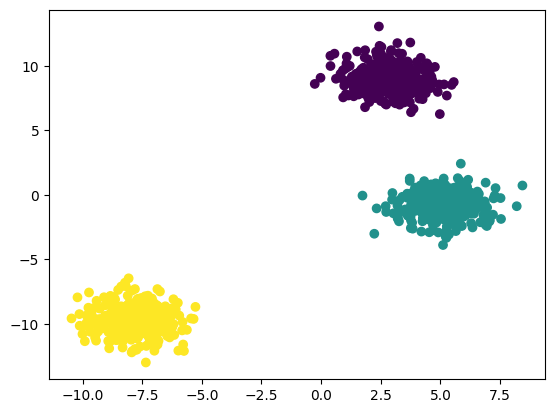

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [11]:
scaler=StandardScaler()

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [15]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
from sklearn.cluster import KMeans

In [17]:
## Elbow method to select K value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [18]:
wcss

[1340.0000000000014,
 219.8508024175983,
 30.332176643601144,
 28.1254588121651,
 21.95356408599875,
 17.76458581262283,
 16.019650534183384,
 14.94653812847335,
 12.938111904505174,
 11.870496835326545]

Text(0, 0.5, 'WCSS')

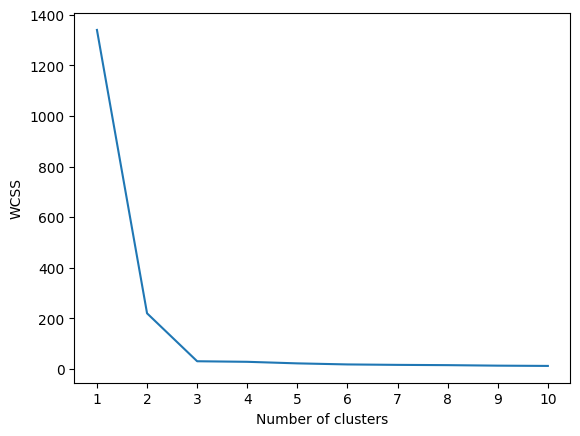

In [19]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")


In [20]:
kmeans=KMeans(n_clusters=k,init="k-means++")

In [21]:
kmeans.fit_predict(X_train_scaled)

array([9, 9, 0, 3, 0, 8, 3, 1, 8, 8, 6, 0, 9, 8, 9, 7, 2, 6, 8, 9, 4, 3,
       4, 4, 9, 3, 0, 5, 6, 3, 9, 1, 9, 7, 3, 7, 3, 1, 5, 4, 0, 2, 1, 0,
       9, 3, 7, 3, 1, 3, 7, 1, 3, 8, 9, 9, 8, 8, 6, 6, 4, 2, 3, 4, 1, 9,
       1, 6, 1, 2, 3, 8, 6, 1, 3, 2, 6, 4, 7, 3, 1, 4, 2, 1, 3, 7, 3, 5,
       4, 4, 2, 8, 6, 8, 3, 7, 4, 8, 0, 8, 3, 4, 7, 4, 6, 2, 2, 7, 0, 6,
       2, 0, 6, 7, 9, 1, 2, 1, 3, 8, 0, 9, 0, 1, 1, 2, 4, 4, 7, 9, 5, 5,
       8, 8, 8, 2, 1, 8, 4, 9, 9, 0, 7, 5, 3, 6, 3, 3, 9, 8, 8, 7, 8, 0,
       5, 6, 2, 1, 7, 9, 7, 3, 8, 0, 1, 1, 5, 3, 6, 7, 1, 9, 3, 7, 9, 6,
       1, 0, 4, 1, 2, 7, 6, 7, 5, 0, 6, 4, 7, 9, 4, 7, 6, 8, 6, 3, 0, 6,
       4, 3, 1, 3, 7, 6, 5, 3, 3, 2, 8, 1, 8, 7, 6, 4, 4, 2, 7, 7, 3, 7,
       4, 2, 7, 0, 6, 9, 6, 8, 4, 2, 2, 0, 1, 4, 3, 0, 7, 1, 2, 4, 2, 4,
       3, 1, 5, 0, 7, 8, 0, 4, 1, 9, 7, 6, 0, 8, 3, 5, 7, 3, 6, 6, 6, 8,
       5, 3, 4, 1, 4, 4, 9, 1, 7, 8, 8, 5, 0, 8, 4, 0, 1, 7, 4, 4, 1, 2,
       8, 7, 7, 3, 7, 3, 5, 9, 6, 0, 4, 7, 7, 3, 0,

In [23]:
y_pred=kmeans.predict(X_test_scaled)

In [24]:
y_pred

array([3, 4, 2, 2, 8, 9, 9, 7, 9, 4, 7, 4, 1, 7, 7, 6, 2, 4, 8, 6, 7, 6,
       4, 5, 3, 2, 6, 7, 5, 7, 3, 8, 0, 8, 9, 4, 1, 9, 6, 7, 6, 5, 0, 5,
       0, 4, 6, 0, 1, 0, 2, 8, 1, 7, 4, 2, 3, 6, 0, 1, 1, 7, 8, 8, 7, 8,
       0, 8, 7, 6, 3, 7, 3, 7, 1, 0, 3, 6, 1, 4, 7, 2, 2, 0, 7, 7, 9, 0,
       6, 7, 9, 4, 1, 0, 8, 4, 1, 4, 6, 2, 8, 1, 0, 6, 7, 2, 7, 2, 6, 3,
       9, 1, 1, 2, 4, 6, 2, 8, 3, 0, 2, 5, 9, 3, 7, 6, 7, 4, 1, 7, 4, 9,
       7, 7, 8, 1, 6, 6, 7, 8, 5, 6, 2, 4, 8, 3, 6, 3, 3, 4, 3, 2, 2, 7,
       7, 6, 2, 3, 2, 6, 2, 9, 1, 1, 8, 8, 3, 9, 7, 8, 9, 7, 3, 5, 4, 3,
       8, 5, 3, 3, 6, 8, 7, 7, 0, 4, 8, 0, 1, 0, 1, 3, 4, 4, 1, 8, 4, 1,
       2, 4, 5, 6, 7, 2, 6, 5, 0, 7, 6, 1, 2, 3, 9, 0, 8, 9, 7, 7, 2, 4,
       8, 2, 9, 6, 2, 7, 6, 4, 2, 4, 4, 9, 3, 7, 5, 1, 1, 9, 7, 0, 6, 7,
       3, 4, 8, 9, 7, 7, 8, 1, 6, 9, 7, 7, 2, 8, 1, 0, 0, 7, 4, 4, 4, 4,
       3, 4, 2, 7, 3, 1, 1, 6, 0, 8, 2, 7, 1, 3, 0, 9, 2, 4, 4, 8, 3, 5,
       9, 0, 0, 1, 9, 6, 9, 7, 9, 5, 7, 2, 7, 4, 1,

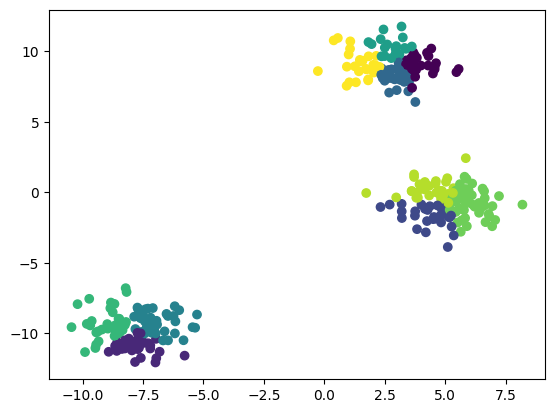

In [27]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [28]:
## Validating the k value
## Knee locator
## silhoutee scoring

In [29]:
##kneelocator
!pip install kneed


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
from kneed import KneeLocator

In [33]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [34]:
kl.elbow

np.int64(3)

In [35]:
  ## silhoutte scoring
from sklearn.metrics import silhouette_score

In [40]:
silhouettee_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouettee_coefficients.append(score)

In [41]:
silhouettee_coefficients

[np.float64(0.7768007443983961),
 np.float64(0.8316941696568949),
 np.float64(0.6747605187718886),
 np.float64(0.5412919693527215),
 np.float64(0.49426501914143),
 np.float64(0.34882727532785),
 np.float64(0.36089056971506017),
 np.float64(0.31357815883754503),
 np.float64(0.3606839984178485)]

Text(0, 0.5, 'Silhouette coefficient')

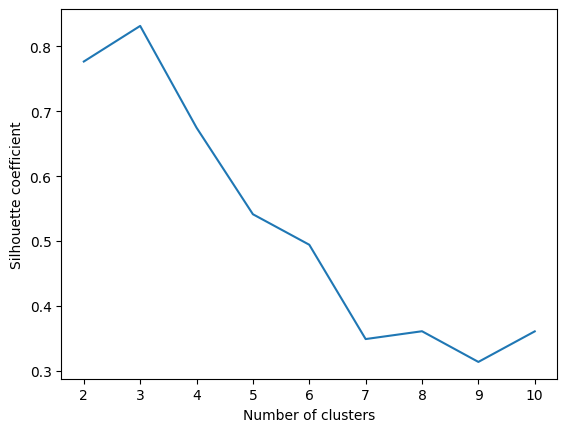

In [43]:
plt.plot(range(2,11),silhouettee_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette coefficient")